## Financials feature engineering

In [6]:
from pyspark.sql.functions import col, lit, when
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder\
    .appName("EDA")\
    .getOrCreate()

# Load cleaned financials and loans
financials = spark.read.parquet("datamart/silver/financials_clean")
loans = spark.read.parquet("datamart/silver/loans_clean")

# Parameters
dpd_cutoff = 30
mob_cutoff = 6

# Get valid snapshot pairs (feature date, label date)
financial_dates = financials.select("snapshot_date").distinct().toPandas()
loan_dates = loans.select("snapshot_date").distinct().toPandas()
financial_dates["snapshot_date"] = pd.to_datetime(financial_dates["snapshot_date"])
loan_dates["snapshot_date"] = pd.to_datetime(loan_dates["snapshot_date"])

valid_pairs = []
for d in sorted(financial_dates["snapshot_date"]):
    label_date = d + pd.DateOffset(months=mob_cutoff)
    if label_date in list(loan_dates["snapshot_date"]):
        valid_pairs.append((d, label_date))

# Build multi-snapshot training set
training_rows = []
for feature_date, label_date in valid_pairs:
    # Get financial snapshot
    f_snap = financials.filter(col("snapshot_date") == lit(feature_date))

    # Get label snapshot
    l_snap = loans.filter(
        (col("snapshot_date") == lit(label_date)) &
        (col("mob") == mob_cutoff)
    ).withColumn("label", when(col("dpd") >= dpd_cutoff, 1).otherwise(0)) \
     .select("Customer_ID", "label")

    # Join and keep snapshot traceability
    joined = f_snap.join(l_snap, on="Customer_ID", how="inner") \
                   .withColumn("feature_snapshot_date", lit(feature_date)) \
                   .withColumn("label_snapshot_date", lit(label_date))

    training_rows.append(joined)

# Merge all
if training_rows:
    training_df = training_rows[0]
    for df in training_rows[1:]:
        training_df = training_df.unionByName(df)

    training_df.cache()
    print(f"✅ Final multi-snapshot training set: {training_df.count()} rows")

    # Save to preview
    os.makedirs("preview", exist_ok=True)
    training_df.limit(1000).toPandas().to_csv("preview/preview_gold_training_financials.csv", index=False)
else:
    print("❌ No valid training data found.")


✅ Final multi-snapshot training set: 12500 rows


In [7]:
training_df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: double (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: double (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: double (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: double (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- M

In [8]:
from pyspark.sql.functions import (
    col, when, coalesce, lit, log1p,
    regexp_extract, size, abs as abs_col
)
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Cap helper
def cap_by_quantile(df, colname, lower_q=0.01, upper_q=0.95):
    q_low, q_high = df.approxQuantile(colname, [lower_q, upper_q], 0.01)
    return df.withColumn(
        colname,
        when(col(colname) < q_low, q_low)
        .when(col(colname) > q_high, q_high)
        .otherwise(col(colname))
    )

# Main function
def build_financial_features(training_df):
    # —————— 1) Impute & Filter ——————
    df = (
        training_df
        .withColumn("Credit_Mix", coalesce(col("Credit_Mix"), lit("Unknown")))
        .withColumn("Payment_Behaviour", coalesce(col("Payment_Behaviour"), lit("Unknown")))
        .withColumn("Changed_Credit_Limit", coalesce(col("Changed_Credit_Limit"), lit(0.0)))
        .filter(col("Monthly_Balance").isNotNull())
    )

    # Impute median Outstanding_Debt
    median_val = df.approxQuantile("Outstanding_Debt", [0.5], 0.01)[0]
    df = df.withColumn("Outstanding_Debt", coalesce(col("Outstanding_Debt"), lit(median_val)))

    # —————— 2) Credit History + Loan Types ——————
    df = (
        df
        .withColumn("history_years", regexp_extract("Credit_History_Age", r"(\d+)\s+Years", 1).cast("int"))
        .withColumn("history_months", regexp_extract("Credit_History_Age", r"(\d+)\s+Months", 1).cast("int"))
        .withColumn("credit_history_months",
                    col("history_years") * 12 + coalesce(col("history_months"), lit(0)))
        .drop("Credit_History_Age", "history_years", "history_months")
        .withColumn("num_loan_types", when(col("Loan_Types_Array").isNotNull(), size(col("Loan_Types_Array"))).otherwise(0))
    )

    # —————— 3) Quantile Capping ——————
    for c in [
        "Num_Bank_Accounts", "Num_Credit_Card",
        "Interest_Rate", "Num_of_Delayed_Payment", "Num_Credit_Inquiries"
    ]:
        df = cap_by_quantile(df, c, lower_q=0.01, upper_q=0.95)

    # —————— 3b) Business Logic Capping ——————
    df = (
        df
        .withColumn("Num_Bank_Accounts", when(col("Num_Bank_Accounts") > 20, 20).otherwise(col("Num_Bank_Accounts")))
        .withColumn("Num_Credit_Card", when(col("Num_Credit_Card") > 10, 10).otherwise(col("Num_Credit_Card")))
        .withColumn("Interest_Rate", when(col("Interest_Rate") > 100, 100).otherwise(col("Interest_Rate")))
        .withColumn("Num_of_Delayed_Payment", when(col("Num_of_Delayed_Payment") > 30, 30).otherwise(col("Num_of_Delayed_Payment")))
        .withColumn("Num_Credit_Inquiries", when(col("Num_Credit_Inquiries") > 20, 20).otherwise(col("Num_Credit_Inquiries")))
    )

    # —————— 4) Log & Ratio Features ——————
    df = (
        df
        .withColumn("log_Annual_Income", log1p(col("Annual_Income")))
        .withColumn("debt_to_income", col("Outstanding_Debt") / (col("Annual_Income") + lit(1.0)))
        .withColumn("emi_to_salary", col("Total_EMI_per_month") / (col("Monthly_Inhand_Salary") + lit(1.0)))
        .withColumn("investment_rate", col("Amount_invested_monthly") / (col("Monthly_Inhand_Salary") + lit(1.0)))
        .withColumn("has_credit_limit_change", when(col("Changed_Credit_Limit") != 0, 1).otherwise(0).cast(IntegerType()))
        .withColumn("credit_limit_decreased", when(col("Changed_Credit_Limit") < 0, 1).otherwise(0).cast(IntegerType()))
        .withColumn("abs_credit_change", abs_col(col("Changed_Credit_Limit")))
        .withColumn("balance_to_debt", (col("Monthly_Balance") + lit(1.0)) / (col("Outstanding_Debt") + lit(1.0)))
        .withColumn("inq_per_loan", col("Num_Credit_Inquiries") / (col("Num_of_Loan") + lit(1.0)))
    )

    # —————— 5) One-Hot Encode Categoricals ——————
    cats = ["Credit_Mix", "Payment_Behaviour", "Payment_of_Min_Amount"]
    indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in cats]
    encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec") for c in cats]
    pipeline = Pipeline(stages=indexers + encoders)
    df = pipeline.fit(df).transform(df)
    df = df.drop(*cats, *[c + "_idx" for c in cats])

    return df


In [9]:
processed_financial_df = build_financial_features(training_df)
pdf = processed_financial_df.toPandas()
pdf.to_csv("gold-financials.csv", index=False)
pdf.head(5)

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,emi_to_salary,investment_rate,has_credit_limit_change,credit_limit_decreased,abs_credit_change,balance_to_debt,inq_per_loan,Credit_Mix_vec,Payment_Behaviour_vec,Payment_of_Min_Amount_vec
0,CUS_0x1037,15989.085,1086.423750,5.0,4.0,2.0,4,"Credit-Builder Loan, Auto Loan, Auto Loan, and...",13,15.0,...,0.031080,0.073996,1,0,0.50,0.427972,0.600000,"(0.0, 1.0, 0.0, 0.0)","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)","(0.0, 1.0, 0.0)"
1,CUS_0x1069,58637.340,4799.445000,4.0,6.0,10.0,119,"Personal Loan, Auto Loan, and Not Specified",9,17.0,...,0.029140,0.034416,1,0,12.56,2.077449,0.041667,"(1.0, 0.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)","(1.0, 0.0, 0.0)"
2,CUS_0x114a,15305.460,1230.455000,0.0,7.0,2.0,2,"Student Loan, and Home Equity Loan",14,2.0,...,0.016486,0.052603,1,0,15.95,0.285137,0.000000,"(0.0, 1.0, 0.0, 0.0)","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)","(0.0, 1.0, 0.0)"
3,CUS_0x1184,19867.475,1396.622917,3.0,5.0,11.0,3,"Student Loan, Mortgage Loan, and Payday Loan",10,9.0,...,0.030485,0.016786,1,0,6.74,0.444161,1.000000,"(0.0, 1.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0)","(0.0, 1.0, 0.0)"
4,CUS_0x1297,57738.060,4881.505000,9.0,8.0,30.0,9,"Payday Loan, Personal Loan, Payday Loan, Perso...",61,23.0,...,0.060683,0.011023,1,0,14.27,0.099310,1.100000,"(0.0, 0.0, 0.0, 1.0)","(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)","(1.0, 0.0, 0.0)"


## Attributes feature 

### EDA

In [15]:
from pyspark.sql.functions import col, lit, when
import pandas as pd
import os

# Load cleaned data
attributes = spark.read.parquet("datamart/silver/attributes_clean")
loans = spark.read.parquet("datamart/silver/loans_clean")

# Parameters
dpd_cutoff = 30
mob_cutoff = 6

# Get valid snapshot dates
attr_dates = attributes.select("snapshot_date").distinct().toPandas()
loan_dates = loans.select("snapshot_date").distinct().toPandas()
attr_dates["snapshot_date"] = pd.to_datetime(attr_dates["snapshot_date"])
loan_dates["snapshot_date"] = pd.to_datetime(loan_dates["snapshot_date"])

valid_pairs = []
for d in sorted(attr_dates["snapshot_date"]):
    label_date = d + pd.DateOffset(months=mob_cutoff)
    if label_date in list(loan_dates["snapshot_date"]):
        valid_pairs.append((d, label_date))

# Build training rows
training_rows = []
for feature_date, label_date in valid_pairs:
    # Get attribute snapshot
    a_snap = attributes.filter(col("snapshot_date") == lit(feature_date))

    # Get label snapshot
    l_snap = loans.filter(
        (col("snapshot_date") == lit(label_date)) &
        (col("mob") == mob_cutoff)
    ).withColumn("label", when(col("dpd") >= dpd_cutoff, 1).otherwise(0)) \
     .select("Customer_ID", "label")

    # Join and tag snapshot dates
    joined = a_snap.join(l_snap, on="Customer_ID", how="inner") \
                   .withColumn("feature_snapshot_date", lit(feature_date)) \
                   .withColumn("label_snapshot_date", lit(label_date))
    
    training_rows.append(joined)

# Combine all
if training_rows:
    attribute_training_df = training_rows[0]
    for df in training_rows[1:]:
        attribute_training_df = attribute_training_df.unionByName(df)

    attribute_training_df.cache()
    print(f"✅ Final multi-snapshot attributes training set: {attribute_training_df.count()} rows")

    # Save preview
    os.makedirs("preview", exist_ok=True)
    attribute_training_df.limit(1000).toPandas().to_csv("preview/preview_gold_training_attributes.csv", index=False)
else:
    print("❌ No valid training data found.")


✅ Final multi-snapshot attributes training set: 12500 rows


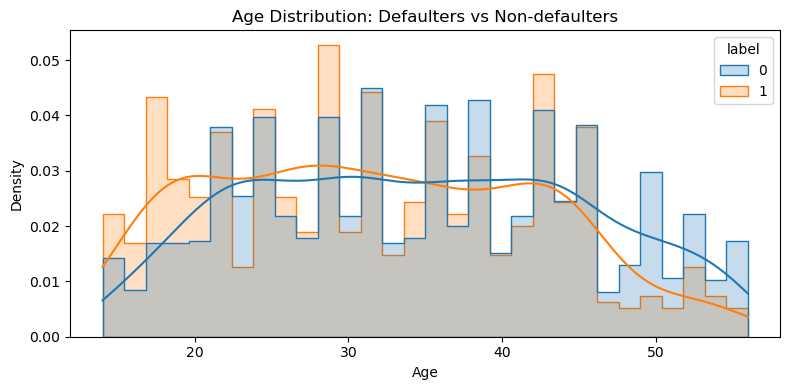

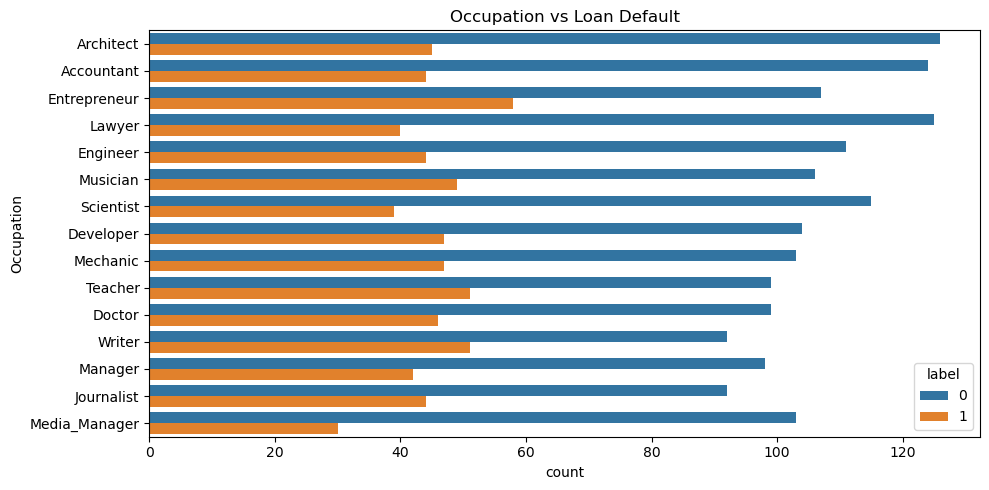

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample a manageable subset for visualization
pdf_attr = attribute_training_df.select("Age", "Occupation", "label").dropna().sample(fraction=0.2, seed=42).toPandas()

# Plot 1: Age distribution by label
plt.figure(figsize=(8, 4))
sns.histplot(data=pdf_attr, x="Age", hue="label", bins=30, kde=True, element="step", stat="density", common_norm=False)
plt.title("Age Distribution: Defaulters vs Non-defaulters")
plt.tight_layout()
plt.show()

# Plot 2: Occupation count by label
plt.figure(figsize=(10, 5))
sns.countplot(data=pdf_attr, y="Occupation", hue="label", order=pdf_attr["Occupation"].value_counts().index)
plt.title("Occupation vs Loan Default")
plt.tight_layout()
plt.show()


### Feature engineering

In [17]:
from pyspark.sql.functions import (
    col, when, coalesce, lit, regexp_replace, isnan
)
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
import pandas as pd
import os

# assume attribute_training_df already exists, with columns:
# Customer_ID, Name, Age, SSN, Occupation, snapshot_date, label, etc.

# 1) Clean & Impute Age
#   - strip out any non-digits
#   - cast to int
#   - drop unrealistic ages (<18 or >100)
#   - impute median for remaining nulls
attr = (
    attribute_training_df
    .withColumn("Age_clean",
        regexp_replace(col("Age"), "[^0-9]", "").cast("int")
    )
    .withColumn("Age_clean",
        when((col("Age_clean") >= 18) & (col("Age_clean") <= 100),
             col("Age_clean"))
        .otherwise(None)
    )
)

# compute median age
median_age = attr.approxQuantile("Age_clean", [0.5], 0.01)[0]

attr = attr.withColumn(
    "Age_clean",
    coalesce(col("Age_clean"), lit(int(median_age)))
)

# 2) Bin Age into groups
attr = (
    attr
    .withColumn("Age_group",
        when(col("Age_clean") < 25, lit("<25"))
       .when(col("Age_clean") < 35, lit("25-34"))
       .when(col("Age_clean") < 50, lit("35-49"))
       .otherwise(lit("50+"))
    )
)

# 3) Clean Occupation
#   - map any null or “_______” to Unknown
#   - group rare ones (< 5% of total) into “Other”
total_count = attr.count()
# get occupations with <5%
counts = attr.groupBy("Occupation").count()
rare_ocs = (
    counts
    .filter(col("count") < total_count * 0.05)
    .select("Occupation")
    .rdd.flatMap(lambda r: r)
    .collect()
)

attr = (
    attr
    .withColumn("Occ_clean",
        when(col("Occupation").isNull(), lit("Unknown"))
       .when(col("Occupation").isin(rare_ocs), lit("Other"))
       .otherwise(col("Occupation"))
    )
)

# 4) One-hot encode Age_group & Occ_clean
cats = ["Age_group","Occ_clean"]
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cats
]
encoders = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec")
    for c in cats
]
pipeline = Pipeline(stages=indexers + encoders)
attr = pipeline.fit(attr).transform(attr)

# drop original & idx cols
attr = attr.drop(*cats, *[c + "_idx" for c in cats])

# 5) Preview & save
os.makedirs("preview", exist_ok=True)
preview_pdf = attr.select(
    "Customer_ID","Age_clean","Age_group_vec","Occ_clean_vec","label"
).toPandas()
preview_csv = "preview/preview_attributes_features.csv"
preview_pdf.to_csv(preview_csv, index=False)
print(f"✅ Saved preview to {preview_csv}")

# show schema & first rows
attr.printSchema()
preview_pdf.head()


✅ Saved preview to preview/preview_attributes_features.csv
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- label: integer (nullable = false)
 |-- feature_snapshot_date: timestamp (nullable = false)
 |-- label_snapshot_date: timestamp (nullable = false)
 |-- Age_clean: integer (nullable = false)
 |-- Age_group_vec: vector (nullable = true)
 |-- Occ_clean_vec: vector (nullable = true)



,Customer_ID,Age_clean,Age_group_vec,Occ_clean_vec,label
0,CUS_0x1037,45,"(1.0, 0.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",0
1,CUS_0x1069,32,"(0.0, 1.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,CUS_0x114a,43,"(1.0, 0.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0
3,CUS_0x1184,49,"(1.0, 0.0, 0.0, 0.0)","(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
4,CUS_0x1297,46,"(1.0, 0.0, 0.0, 0.0)","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1


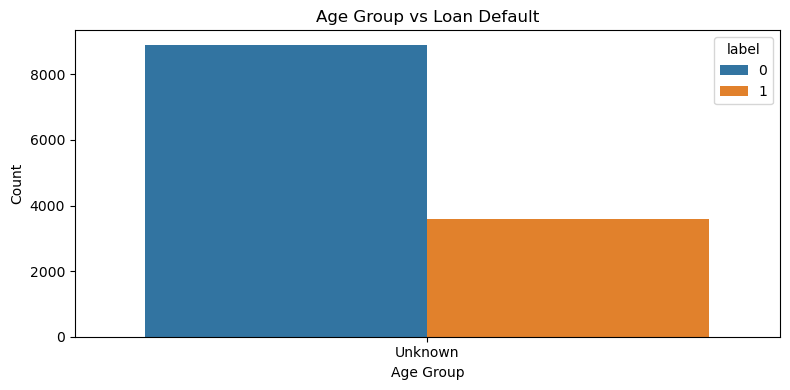

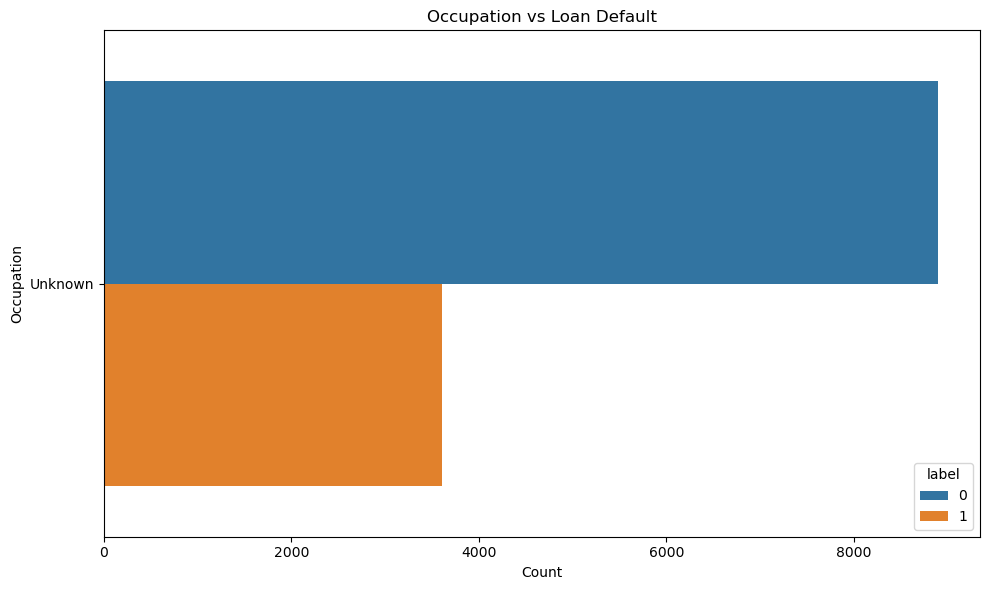

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the saved CSV preview
df = pd.read_csv("preview/preview_attributes_features.csv")

# Plot Age group one-hot distribution vs label
# First, infer age group from one-hot vector positions
age_group_labels = ["<25", "25-34", "35-49", "50+"]
df["Age_group"] = df["Age_group_vec"].apply(lambda x: age_group_labels[x.index(1)] if isinstance(x, list) and 1 in x else "Unknown")

# Plot
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Age_group", hue="label")
plt.title("Age Group vs Loan Default")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# For Occupation: convert sparse vector to inferred category
# (This assumes the encoded order is known — here we use placeholder for demo)
# NOTE: In real usage, you'd extract the StringIndexer model labels
occupation_labels = ["Accountant", "Engineer", "Lawyer", "Teacher", "Doctor", "Other", "Unknown"]
df["Occ_clean"] = df["Occ_clean_vec"].apply(lambda x: occupation_labels[x.index(1)] if isinstance(x, list) and 1 in x else "Unknown")

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Occ_clean", hue="label")
plt.title("Occupation vs Loan Default")
plt.xlabel("Count")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()


In [19]:
attribute_training_df.printSchema()


root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- label: integer (nullable = false)
 |-- feature_snapshot_date: timestamp (nullable = false)
 |-- label_snapshot_date: timestamp (nullable = false)



In [20]:
attribute_training_df.select("Age", "Occupation").show(10, truncate=False)


+---+----------+
|Age|Occupation|
+---+----------+
|45 |Accountant|
|32 |Accountant|
|43 |Developer |
|49 |Lawyer    |
|46 |Manager   |
|35 |Doctor    |
|27 |Accountant|
|47 |Mechanic  |
|15 |Lawyer    |
|41 |Journalist|
+---+----------+
only showing top 10 rows



In [22]:
from pyspark.sql.functions import col, when

# Assume `attribute_training_df` is your Spark DataFrame
attribute_training_df = attribute_training_df.withColumn("Age", col("Age").cast("int"))

attribute_training_df = attribute_training_df.withColumn(
    "Age_Group",
    when(col("Age").isNull(), "Unknown")
    .when(col("Age") < 25, "Under 25")
    .when(col("Age").between(25, 34), "25-34")
    .when(col("Age").between(35, 44), "35-44")
    .when(col("Age").between(45, 54), "45-54")
    .when(col("Age") >= 55, "55+")
    .otherwise("Unknown")
)

attribute_training_df = attribute_training_df.withColumn(
    "Occupation_Clean",
    when(col("Occupation").isNull(), "Unknown")
    .otherwise(col("Occupation"))
)

# Show group count to confirm fix
attribute_training_df.groupBy("Age_Group").count().show()


+---------+-----+
|Age_Group|count|
+---------+-----+
|    45-54| 1917|
|  Unknown|  319|
| Under 25| 2963|
|    35-44| 3500|
|    25-34| 3536|
|      55+|  265|
+---------+-----+



## Clickstream features

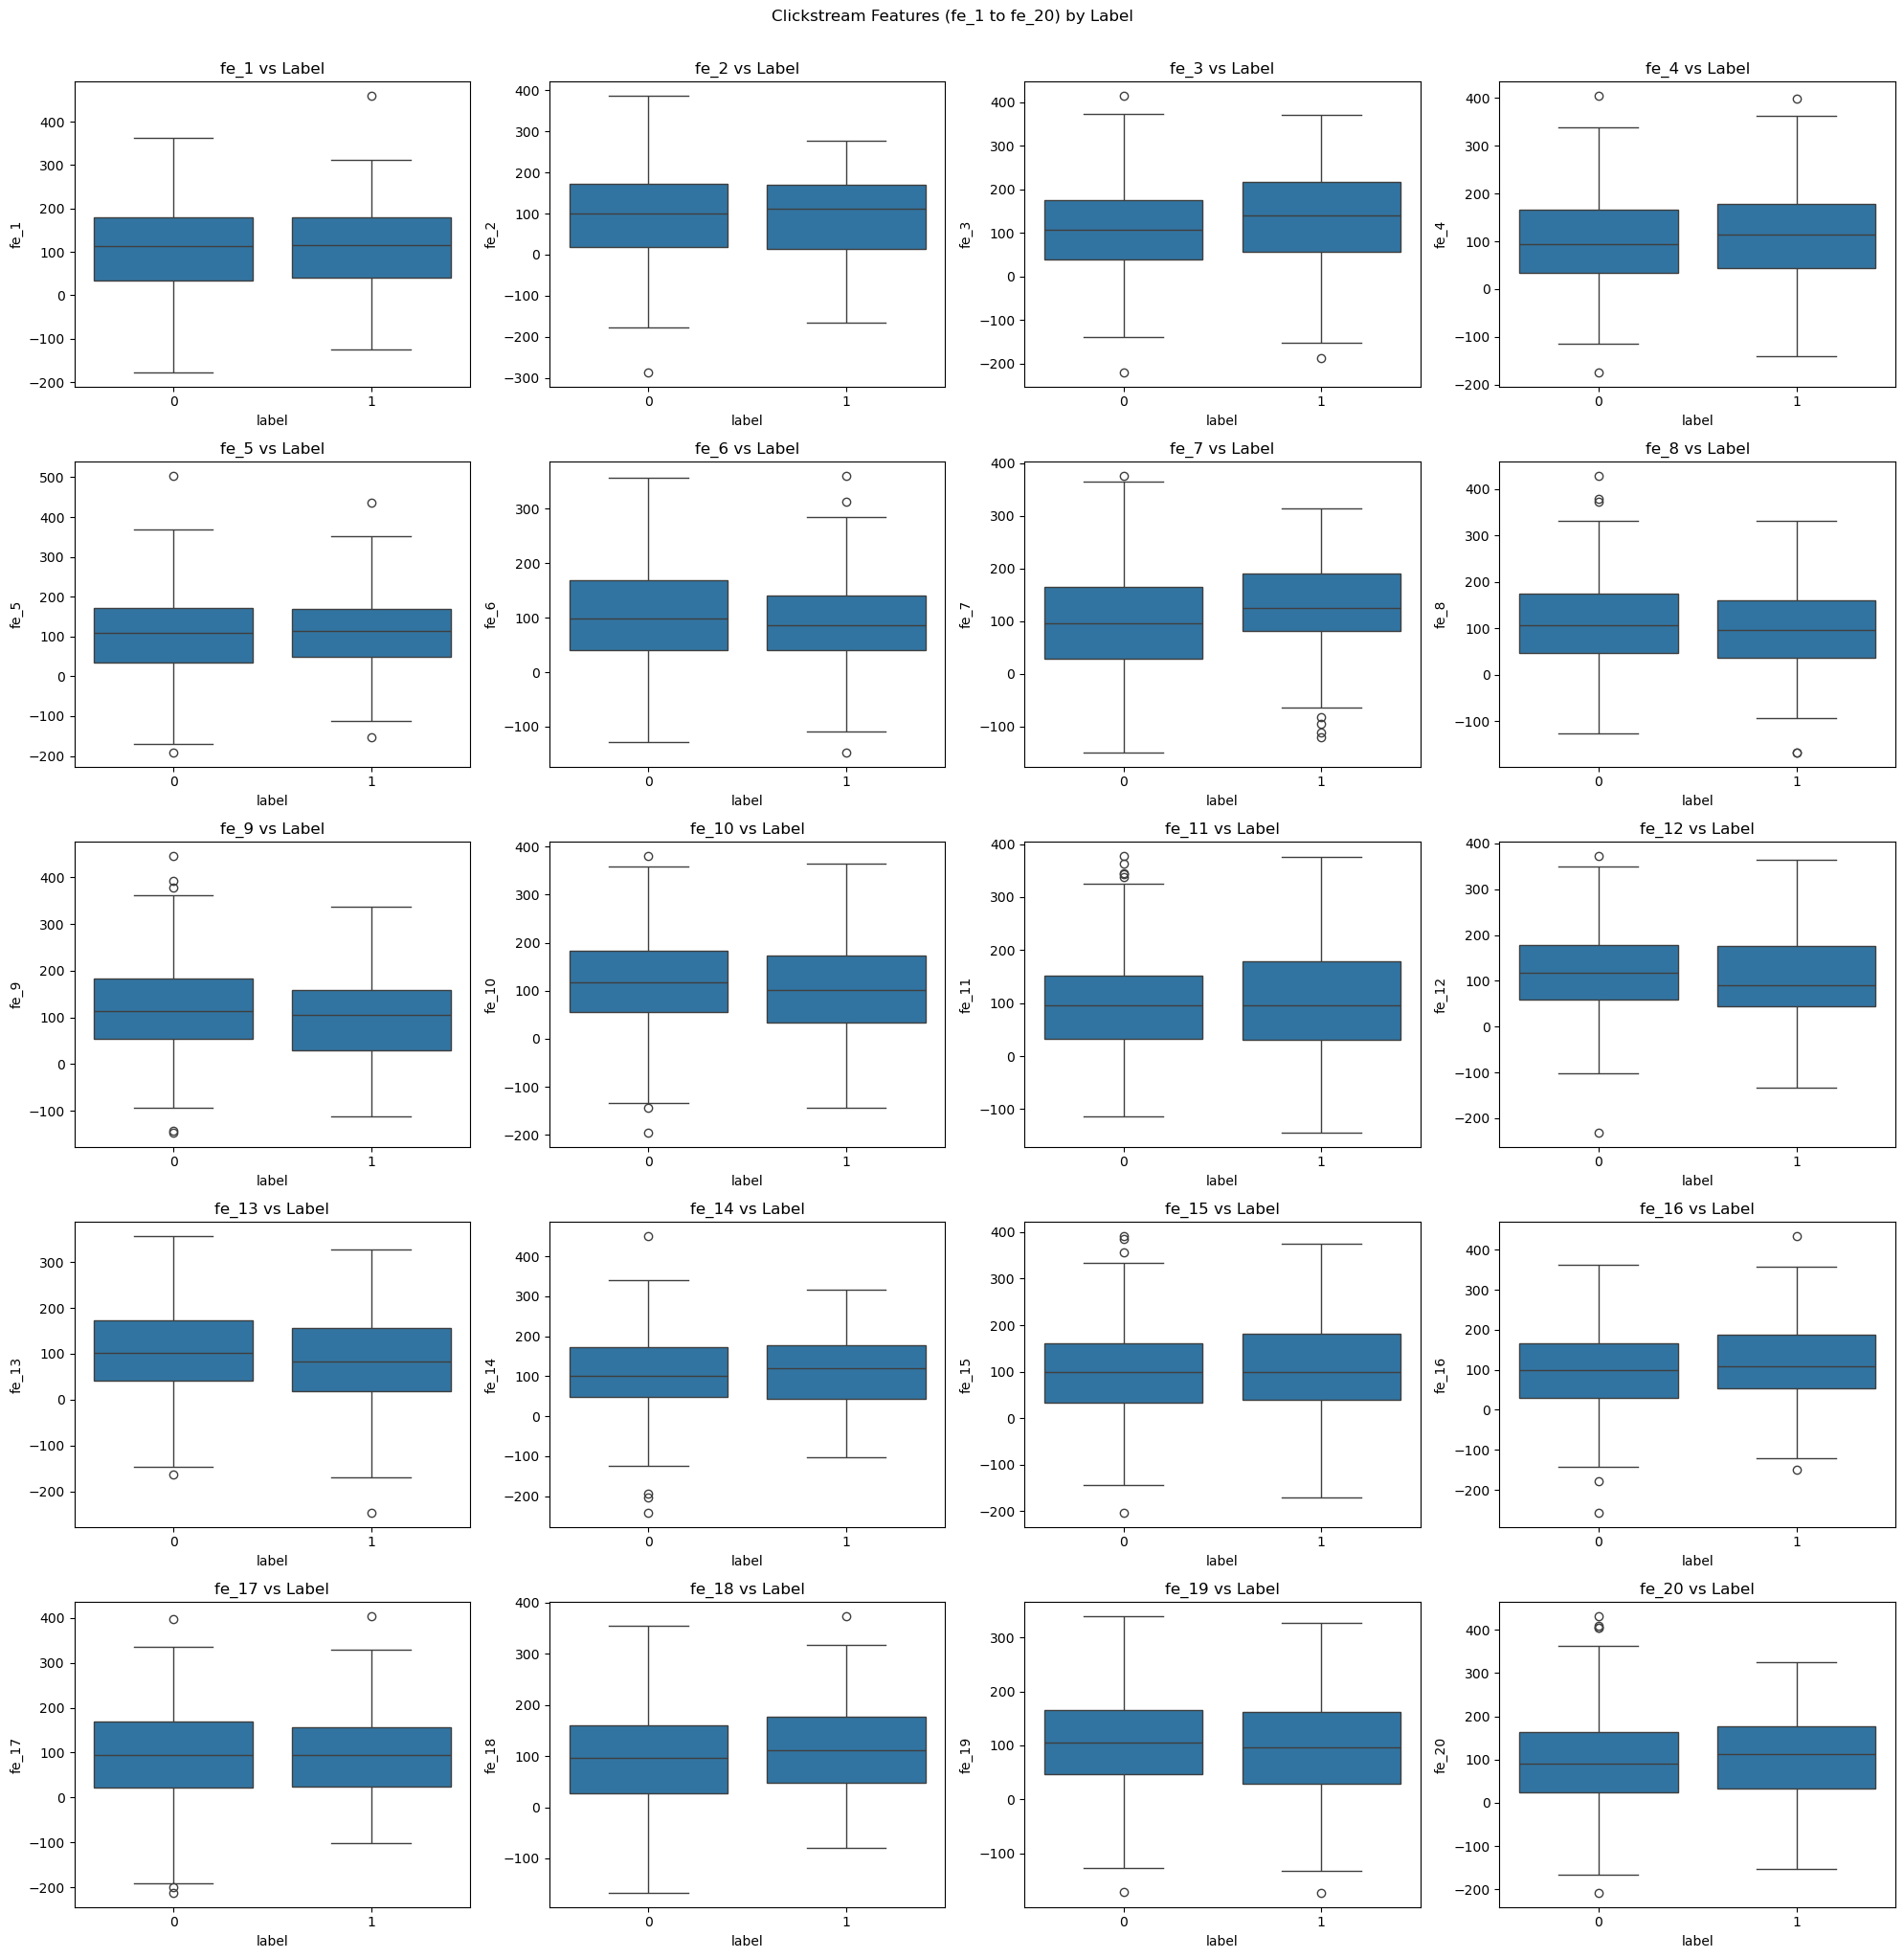

In [24]:
from pyspark.sql.functions import col, lit, when
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load silver stage data
clickstream_df = spark.read.parquet("datamart/silver/clickstream_clean")
loans_df = spark.read.parquet("datamart/silver/loans_clean")

# Define parameters
mob_cutoff = 6
dpd_cutoff = 30

# Get distinct snapshot dates
click_dates = clickstream_df.select("snapshot_date").distinct().toPandas()
loan_dates = loans_df.select("snapshot_date").distinct().toPandas()

# Convert to datetime
click_dates["snapshot_date"] = pd.to_datetime(click_dates["snapshot_date"])
loan_dates["snapshot_date"] = pd.to_datetime(loan_dates["snapshot_date"])

# Determine valid snapshot pairs (clickstream_date, label_date)
valid_click_pairs = []
for d in sorted(click_dates["snapshot_date"]):
    label_date = d + pd.DateOffset(months=mob_cutoff)
    if label_date in set(loan_dates["snapshot_date"]):
        valid_click_pairs.append((d, label_date))

# Build multi-snapshot join
click_rows = []
for click_date, label_date in valid_click_pairs:
    f_snap = clickstream_df.filter(col("snapshot_date") == lit(click_date))
    l_snap = loans_df.filter(
        (col("snapshot_date") == lit(label_date)) &
        (col("mob") == mob_cutoff)
    ).withColumn("label", when(col("dpd") >= dpd_cutoff, 1).otherwise(0)) \
     .select("Customer_ID", "label")

    joined = f_snap.join(l_snap, on="Customer_ID", how="inner") \
                   .withColumn("feature_snapshot_date", lit(click_date)) \
                   .withColumn("label_snapshot_date", lit(label_date))
    click_rows.append(joined)

# Merge all and plot
if click_rows:
    click_training_df = click_rows[0]
    for df in click_rows[1:]:
        click_training_df = click_training_df.unionByName(df)
    click_training_df.cache()

    # Sample and convert to Pandas
    pdf = click_training_df.sample(fraction=0.05, seed=42).toPandas()

    # Plot all 20 features
    fe_cols = [f"fe_{i}" for i in range(1, 21)]
    n_cols = 4
    n_rows = (len(fe_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    for idx, fe in enumerate(fe_cols):
        row, col = divmod(idx, n_cols)
        sns.boxplot(data=pdf, x="label", y=fe, ax=axes[row, col])
        axes[row, col].set_title(f"{fe} vs Label")

    # Hide any unused subplots
    for i in range(len(fe_cols), n_rows * n_cols):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.suptitle("Clickstream Features (fe_1 to fe_20) by Label", y=1.02)
    plt.show()

else:
    print("❌ No valid multi-snapshot clickstream training data found.")


In [2]:
import pandas as pd
df = pd.read_csv("preview/gold_ml_feature_store.csv")

In [3]:
df.shape

(8973, 45)

In [4]:
df.columns

Index(['Customer_ID', 'feature_snapshot_date', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Monthly_Balance',
       'credit_history_months', 'num_loan_types', 'log_Annual_Income',
       'debt_to_income', 'emi_to_salary', 'investment_rate',
       'has_credit_limit_change', 'balance_to_debt', 'inq_per_loan',
       'Credit_Mix_vec', 'Payment_Behaviour_vec', 'Payment_of_Min_Amount_vec',
       'Occupation_vec', 'Age_group_vec', 'fe_1', 'fe_2', 'fe_3', 'fe_4',
       'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12',
       'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20'],
      dtype='object')

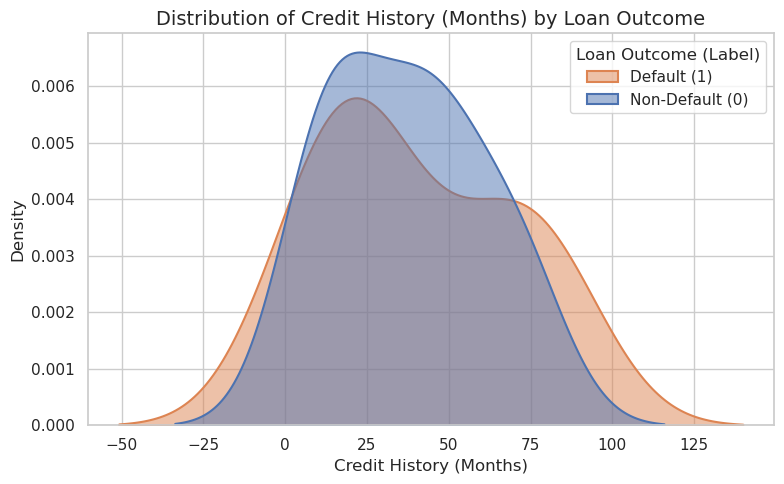

/tmp/ipykernel_730/3527307667.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='credit_history_months', data=df, palette="viridis")


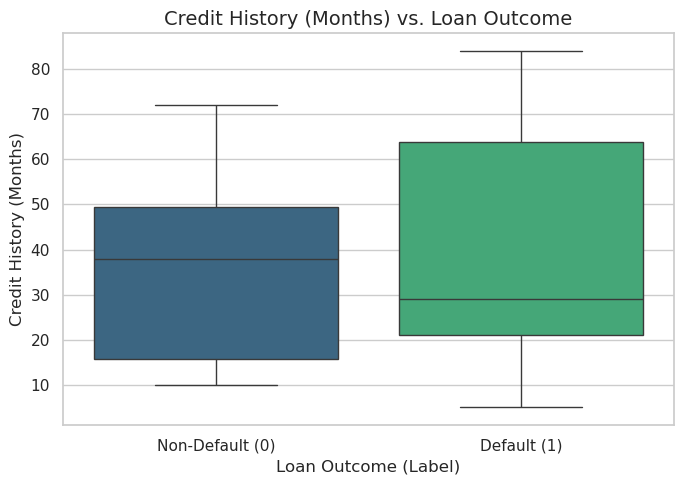

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has 'credit_history_months' and 'label' columns
# For demonstration, let's create a sample DataFrame
# Replace this with your actual DataFrame
data_sample = {
    'credit_history_months': [12, 24, 36, 6, 48, 60, 18, 30, 72, 84, 10, 20, 50, 5, 40, 65, 15, 28, 70, 80],
    'label': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
    # Add other columns from your list if needed for a more complete sample,
    # but for this plot, only these two are essential.
}
df = pd.DataFrame(data_sample)


# --- Plot 1: Density Plot of Credit History Months by Label ---
plt.figure(figsize=(8, 5)) # Adjust size as needed for your slide
sns.set_theme(style="whitegrid")

sns.kdeplot(data=df, x='credit_history_months', hue='label', fill=True, alpha=.5, linewidth=1.5)

plt.title('Distribution of Credit History (Months) by Loan Outcome', fontsize=14)
plt.xlabel('Credit History (Months)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Loan Outcome (Label)', labels=['Default (1)', 'Non-Default (0)']) # Adjust labels if your 0/1 mapping is different
plt.tight_layout()
plt.show()


# --- Plot 2: Box Plot of Credit History Months by Label ---
plt.figure(figsize=(7, 5)) # Adjust size as needed
sns.set_theme(style="whitegrid")

sns.boxplot(x='label', y='credit_history_months', data=df, palette="viridis")

plt.title('Credit History (Months) vs. Loan Outcome', fontsize=14)
plt.xlabel('Loan Outcome (Label)', fontsize=12)
plt.ylabel('Credit History (Months)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Default (0)', 'Default (1)']) # Adjust labels if needed
plt.tight_layout()
plt.show()